# Clustering Time Series: A Hands-On Tutorial

*Week 2 companion to the Game Theory & Behavioral Game Theory primer — Konstanz 2026.*

In many social-science experiments you observe the **same variable over time** for many participants: how much they cooperate, how much they trust, how they vote. Every participant is a little *time series*. A natural question is: are there **types** of people who behave similarly over time?

That is a **clustering** question. In this notebook we will:

1. **Look at the data** — contributions in a public-goods game, one row per participant per round.
2. **Meet the three ingredients of any clustering analysis** — number of clusters, distance metric, algorithm — and see why step 2 (distance) deserves more attention than it usually gets.
3. **Work through each ingredient** on the real data.
4. **Recover the six behavioural types** reported in the paper and compare them to the canonical public-goods typology.

### The data in one sentence
Each participant plays a public-goods game for 10 rounds. In every round they choose how much of their endowment to **contribute** (`contr_nrmd`, normalized to [0, 1]) and they observe the average contribution of the **others** in their group (`contr_oth_nrmd`). Data are from Engel & Kurschilgen (2020) and Diedrich et al. (2016), pooled together.

### How this fits the course
This tutorial is the hands-on counterpart to today's primer on behavioral game theory. We deliberately work with **human data only** — no LLMs yet. The pipeline (DTW + spectral clustering) is a simplified version of Hausladen, Engel & Schubert (2026, *arXiv:2601.08803*, in `papers/game theory/Hausladen_2026_PGGIntentions.pdf`).

**Running theme — transfer principle.** Next week we turn to the LLM papers. While you run this notebook, keep a running list: *which of these methodological moves would transfer to an LLM played repeatedly against a partner? Which would break, and why?* We come back to that list in Week 3.

## 0. Setup

We use `pandas` for data handling, `matplotlib` + `seaborn` for plots, `scikit-learn` for clustering algorithms, and `tslearn` for the time-series distance (Dynamic Time Warping, which we'll explain later).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import SpectralClustering, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score
from tslearn.metrics import cdist_dtw, dtw_path
from tslearn.utils import to_time_series_dataset

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

## 1. Load the data

We load a small prepared CSV (`pgg_10rounds.csv`) that already contains only what we need:

| column | meaning |
| --- | --- |
| `uid` | participant ID (integer) |
| `period` | round number, 1 to 10 |
| `contr_nrmd` | own contribution this round, in [0, 1] |
| `contr_oth_nrmd` | mean contribution of others in the group, in [0, 1] |

That's 362 participants × 10 rounds = 3620 rows. Tiny.

In [ ]:
data = pd.read_csv('pgg_10rounds.csv')
print('rows:', len(data), ' participants:', data['uid'].nunique())
data.head()

### First try: the obvious plot

If you had never seen this dataset before, what's the *first* plot you'd reach for? Probably a **line plot**: round on the x-axis, contribution on the y-axis, one line per participant. Let's do exactly that.

We'll first plot **five random participants** — readable — and then plot **all 362** on top of each other to show what happens when you scale up.

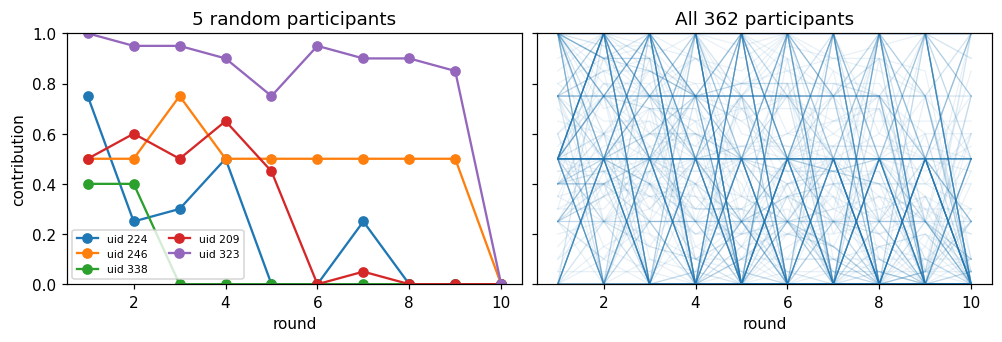

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True, constrained_layout=True)

# Left: 5 random participants, connect the dots
rng = np.random.default_rng(7)
sample_uids = rng.choice(data['uid'].unique(), size=5, replace=False)
for u in sample_uids:
    sub = data[data['uid'] == u]
    axes[0].plot(sub['period'], sub['contr_nrmd'], marker='o', label=f'uid {u}')
axes[0].set_title('5 random participants')
axes[0].set_xlabel('round'); axes[0].set_ylabel('contribution'); axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=7, ncol=2)

# Right: all 362 participants, same plot
for u in data['uid'].unique():
    sub = data[data['uid'] == u]
    axes[1].plot(sub['period'], sub['contr_nrmd'], color='tab:blue', alpha=0.1, lw=0.8)
axes[1].set_title('All 362 participants')
axes[1].set_xlabel('round'); axes[1].set_ylim(0, 1)
plt.show()

**The problem.** The left panel is readable, but five participants is *not* our dataset. The right panel is our dataset, and it's a hairball — you can't see patterns, you can't count types, you can't even tell where the density is. Lines *overlap* and *occlude* each other.

We need a representation that shows **every participant at once without occlusion**. The trick is to stop using the y-axis for the value and use **colour** instead: one row per participant, one column per round, colour = contribution. That is a **heatmap**.

### Better: one heatmap row per participant

Now we sort participants by their average contribution so that cooperators end up at the top and free-riders at the bottom. Two heatmaps side by side:

- **Own contribution** — the participant's own action each round.
- **Others' contribution** — what the participant saw their group do.

The goal of clustering, later, will be to replace these two big pictures with a small number of **prototype trajectories** — one per type of player.

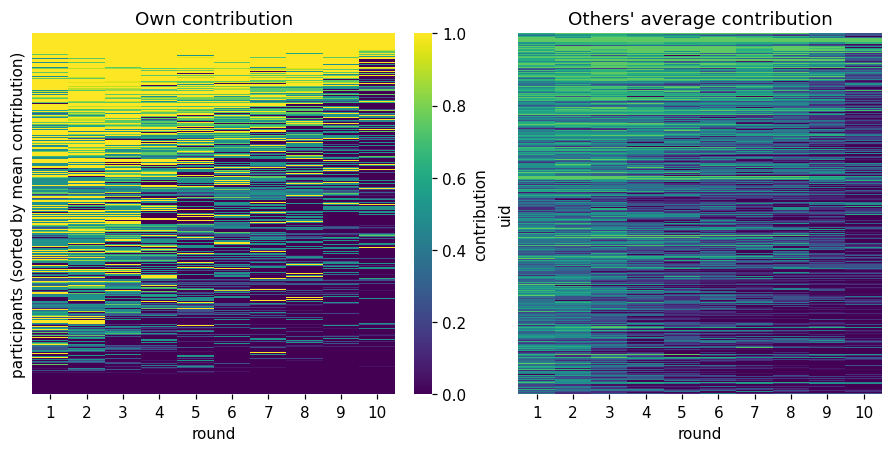

In [4]:
uid_order = data.groupby('uid')['contr_nrmd'].mean().sort_values(ascending=False).index
own    = data.pivot(index='uid', columns='period', values='contr_nrmd').loc[uid_order]
others = data.pivot(index='uid', columns='period', values='contr_oth_nrmd').loc[uid_order]

fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
sns.heatmap(own, ax=axes[0], cmap='viridis', vmin=0, vmax=1, cbar=True,
            yticklabels=False, cbar_kws={'label': 'contribution'})
sns.heatmap(others, ax=axes[1], cmap='viridis', vmin=0, vmax=1, cbar=False,
            yticklabels=False)
axes[0].set_title('Own contribution')
axes[1].set_title("Others' average contribution")
for ax in axes:
    ax.set_xlabel('round')
axes[0].set_ylabel('participants (sorted by mean contribution)')
plt.show()

**What do you see?** Two things stand out.

1. There is a **gradient** from cooperators (top) to free-riders (bottom) — so a 1-D summary (`mean contribution`) captures a lot.
2. But within that gradient you see **temporal patterns**: some participants start high and decline, some start low and climb, some are volatile. A single average throws those away.

That is the motivation for time-series clustering: we want clusters that respect *when* things happen, not just *how much* on average.

## 2. The three ingredients of clustering

You've probably heard of clustering before. But are you aware that every clustering analysis actually has **three** specific choices to make?

1. **How many clusters** (`k`)?
2. **What distance metric** — how do we measure similarity between two data points?
3. **Which algorithm** groups the points together?

Most tutorials spend a lot of attention on **steps 1 and 3**. Step 2 is usually not even discussed — the silent assumption is **Euclidean distance**, and the conversation moves on.

We're going to flip that order. We'll look at step 2 *first*, because for **time series** the choice of distance matters a lot. Two quick pictures will show you why.

### Euclidean distance in one sentence
Stand two curves next to each other and, at every round, measure the vertical gap. Sum the squared gaps. Done.

That works when curves are **phase-aligned** — their ups and downs happen at the same rounds. It **fails** when one curve is shifted in time: two sine curves with the same *shape* can look very far apart simply because they peak at different rounds.

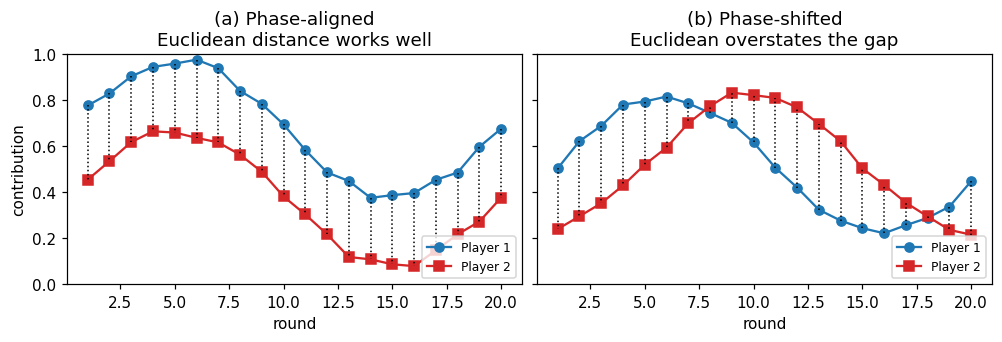

Euclidean, aligned (really different):  1.34
Euclidean, shifted (same shape!):      1.12


In [5]:
def sine_curve(shift, offset, amp=0.3, n=20, noise=0.05, rng=None):
    rng = rng if rng is not None else np.random.default_rng(0)
    x = np.arange(1, n + 1)
    y = offset + amp * np.sin((x - shift) / n * 2 * np.pi) + rng.random(n) * noise
    return x, y

rng = np.random.default_rng(123)
x, y_top = sine_curve(shift=0, offset=0.65, rng=rng)
x, y_bot = sine_curve(shift=0, offset=0.35, rng=rng)
x, y_a   = sine_curve(shift=1, offset=0.5,  rng=rng)
x, y_b   = sine_curve(shift=5, offset=0.5,  rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True, constrained_layout=True)

# (a) phase-aligned
ax = axes[0]
ax.plot(x, y_top, marker='o', color='tab:blue', label='Player 1')
ax.plot(x, y_bot, marker='s', color='tab:red',  label='Player 2')
for xi, a, b in zip(x, y_top, y_bot):
    ax.plot([xi, xi], [a, b], ls=':', color='k', lw=1)
ax.set_title('(a) Phase-aligned\nEuclidean distance works well')
ax.set_xlabel('round'); ax.set_ylabel('contribution'); ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=8)

# (b) phase-shifted
ax = axes[1]
ax.plot(x, y_a, marker='o', color='tab:blue', label='Player 1')
ax.plot(x, y_b, marker='s', color='tab:red',  label='Player 2')
for xi, a, b in zip(x, y_a, y_b):
    ax.plot([xi, xi], [a, b], ls=':', color='k', lw=1)
ax.set_title('(b) Phase-shifted\nEuclidean overstates the gap')
ax.set_xlabel('round'); ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=8)

plt.show()

print(f'Euclidean, aligned (really different):  {np.sqrt(np.sum((y_top - y_bot)**2)):.2f}')
print(f'Euclidean, shifted (same shape!):      {np.sqrt(np.sum((y_a   - y_b  )**2)):.2f}')

**Read the numbers.** In panel (a) the two curves really *are* different (different levels). In panel (b) they are essentially the same curve, only one peaks a few rounds later. Yet Euclidean distance calls them similarly far apart.

For time series with phase shifts we want a smarter distance. The one we use below is **Dynamic Time Warping (DTW)**. Intuitively, DTW is allowed to stretch the time axis of one curve to find the best alignment with the other, and *then* measures the gap. Two copies of the same shape, shifted in time, get a small DTW distance.

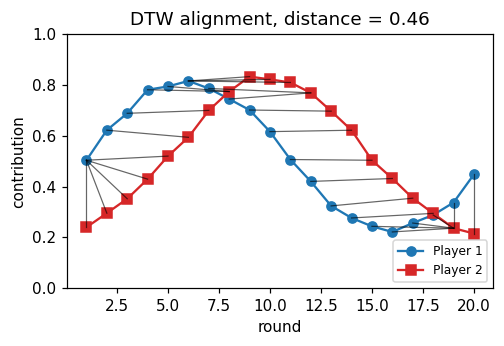

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, y_a, marker='o', color='tab:blue', label='Player 1')
ax.plot(x, y_b, marker='s', color='tab:red',  label='Player 2')
path, dtw_d = dtw_path(y_a, y_b)
for i, j in path:
    ax.plot([x[i], x[j]], [y_a[i], y_b[j]], color='k', lw=0.8, alpha=0.6)
ax.set_title(f'DTW alignment, distance = {dtw_d:.2f}')
ax.set_xlabel('round'); ax.set_ylabel('contribution'); ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=8)
plt.show()

## 3. Compute the DTW distance matrix

Step 2 is settled: we use **DTW**. Now we compute it once, for every pair of participants, and reuse the matrix for everything that follows.

### Why DTW has to see *both* channels

Each participant has two numbers every round: their own contribution, and the average contribution of the others in their group. We could hand DTW just the own-contribution curve. We don't. We hand DTW a **two-channel time series** — own *and* others' at every round — and the algorithm computes similarity jointly over both channels at the same time.

That matters, because a public-goods game is not a solo task: what you choose depends on what you see. Two participants can have **the exact same own-contribution trajectory for very different reasons**:

- One contributes 0.5 in a group where everyone else contributes 0.5. They're matching the crowd — a **conditional cooperator**.
- Another contributes 0.5 in a group where everyone else is free-riding at 0. They're *unconditionally* cooperative — a rare and very different type.

If we clustered on own contribution alone, those two land in the same cluster and we'd never tell them apart. With both channels, DTW sees that the *contexts* are different and separates them. The resulting clusters become **behavioural strategies** (how you respond to what others do), not just **behavioural averages** (how much you contribute on average).

More formally, each participant's trajectory is a path through a joint **(state, action) space** — state = what I observed others do, action = what I chose. Clustering on the joint path is what lets economists and political scientists read off *types* such as free-rider, imitator, conditional cooperator, or hump-shaped contributor. That is the whole point of the exercise.

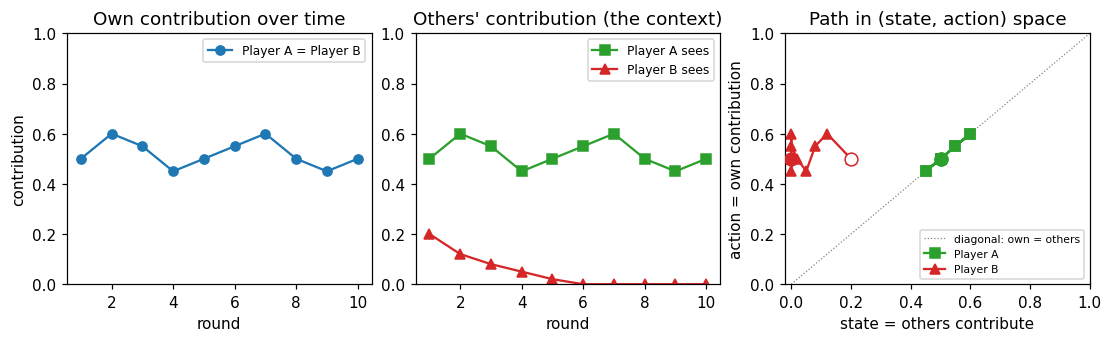

In [7]:
# Schematic: two made-up players with IDENTICAL own-contribution curves
# but very different contexts — so they are different "types".
rounds = np.arange(1, 11)
own_shared = np.array([0.5, 0.6, 0.55, 0.45, 0.5, 0.55, 0.6, 0.5, 0.45, 0.5])

# Player A: lives in a cooperative group, matches whatever others do
others_A = own_shared.copy()

# Player B: lives in a group that free-rides — but contributes anyway
others_B = np.array([0.20, 0.12, 0.08, 0.05, 0.02, 0.0, 0.0, 0.0, 0.0, 0.0])

fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)

# Panel 1: own contribution over time — the two curves are identical
axes[0].plot(rounds, own_shared, 'o-', color='tab:blue',
             label='Player A = Player B')
axes[0].set_title('Own contribution over time')
axes[0].set_xlabel('round'); axes[0].set_ylabel('contribution')
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8, loc='upper right')

# Panel 2: what each player sees — very different contexts
axes[1].plot(rounds, others_A, 's-', color='tab:green', label='Player A sees')
axes[1].plot(rounds, others_B, '^-', color='tab:red',   label='Player B sees')
axes[1].set_title("Others' contribution (the context)")
axes[1].set_xlabel('round'); axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8, loc='upper right')

# Panel 3: path in the 2-D (state, action) space that DTW actually sees
axes[2].plot([0, 1], [0, 1], ls=':', color='grey', lw=0.8,
             label='diagonal: own = others')
axes[2].plot(others_A, own_shared, 's-', color='tab:green', label='Player A')
axes[2].plot(others_B, own_shared, '^-', color='tab:red',   label='Player B')
# Hollow marker = round 1, solid marker = round 10
for xs, ys, c in [(others_A, own_shared, 'tab:green'),
                  (others_B, own_shared, 'tab:red')]:
    axes[2].scatter(xs[0],  ys[0],  s=70, facecolor='white',
                    edgecolor=c, zorder=5)
    axes[2].scatter(xs[-1], ys[-1], s=70, color=c, zorder=5)
axes[2].set_title('Path in (state, action) space')
axes[2].set_xlabel('state = others contribute')
axes[2].set_ylabel('action = own contribution')
axes[2].set_xlim(-0.02, 1); axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=7, loc='lower right')
plt.show()

In the **left** panel the two players look identical — if we clustered on *own contribution alone*, DTW would call them the same type. The **middle** panel shows they actually experienced totally different groups. The **right** panel is the view DTW gets when we feed it *both* channels: now the two players live in different parts of the (state, action) space and end up in different clusters. Hollow marker = round 1, solid marker = round 10.

In [8]:
uids = data['uid'].unique()
ts_list = [data[data['uid'] == u][['contr_nrmd', 'contr_oth_nrmd']].values for u in uids]
tsd = to_time_series_dataset(ts_list)
print('time-series tensor (participants, rounds, channels):', tsd.shape)

# Pairwise DTW distances — takes ~1 minute on a laptop
D = cdist_dtw(tsd)
# Turn distances into similarities for spectral clustering (Gaussian kernel)
S = np.exp(-D ** 2 / (2 * np.var(D)))
print('distance matrix:', D.shape)

time-series tensor (participants, rounds, channels): (362, 10, 2)


distance matrix: (362, 362)


## Step 1 — How many clusters?

We fit spectral clustering for `k = 2, ..., 12` and evaluate each fit with three scores. We then **normalize** each score to [0, 1] and **average** them.

- **Silhouette** (higher is better): how much closer a point is to its own cluster than to the next-closest cluster.
- **Calinski–Harabasz** (higher is better): ratio of between-cluster variance to within-cluster variance.
- **Intra-cluster variance** (lower is better, so we flip it): average distance *within* a cluster.

The paper reports **6 clusters**. We will pick `k = 6` and use the CVI plot as a sanity check: the averaged score should be near its maximum there, not far from it.

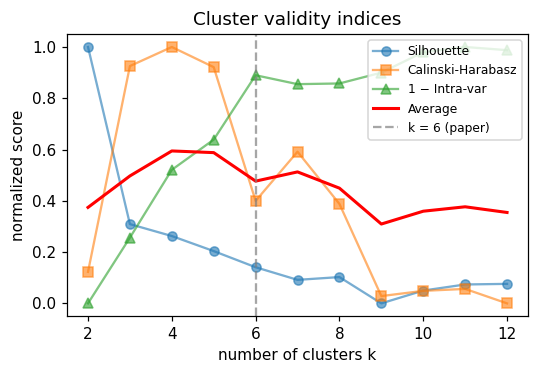

In [9]:
def intra_cluster_variance(D, labels):
    return np.mean([
        D[np.ix_(np.where(labels == c)[0], np.where(labels == c)[0])].mean()
        for c in np.unique(labels)
    ])

ks = range(2, 13)
scores = {'Silhouette': [], 'Calinski-Harabasz': [], 'Intra-cluster Variance': []}
for kk in ks:
    lbl = SpectralClustering(n_clusters=kk, affinity='precomputed',
                              random_state=42).fit_predict(S)
    scores['Silhouette'].append(silhouette_score(D, lbl, metric='precomputed'))
    scores['Calinski-Harabasz'].append(calinski_harabasz_score(S, lbl))
    scores['Intra-cluster Variance'].append(intra_cluster_variance(D, lbl))

def norm(vs):
    vs = np.array(vs); lo, hi = vs.min(), vs.max()
    return (vs - lo) / (hi - lo) if hi > lo else np.zeros_like(vs)

n_sil = norm(scores['Silhouette'])
n_ch  = norm(scores['Calinski-Harabasz'])
n_iv  = 1 - norm(scores['Intra-cluster Variance'])
avg   = (n_sil + n_ch + n_iv) / 3

plt.figure(figsize=(5, 3.5))
plt.plot(ks, n_sil, 'o-', label='Silhouette', alpha=0.6)
plt.plot(ks, n_ch,  's-', label='Calinski-Harabasz', alpha=0.6)
plt.plot(ks, n_iv,  '^-', label='1 − Intra-var', alpha=0.6)
plt.plot(ks, avg,   'r-', lw=2, label='Average')
plt.axvline(6, color='grey', ls='--', alpha=0.7, label='k = 6 (paper)')
plt.xlabel('number of clusters k'); plt.ylabel('normalized score')
plt.title('Cluster validity indices')
plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 2 — The distance metric (already done)

We already committed to **DTW** in section 2 and computed the DTW distance matrix `D` once. Visualizing `D` sorted by mean contribution shows the **block structure** along the diagonal that spectral clustering will exploit — participants who contribute similarly cluster near one another.

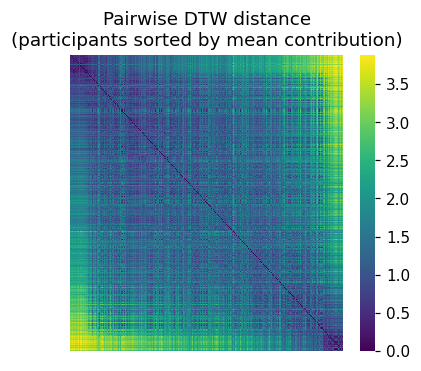

In [10]:
series_mean = np.array([data[data['uid'] == u]['contr_nrmd'].mean() for u in uids])
order = np.argsort(series_mean)

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(D[np.ix_(order, order)], ax=ax, cmap='viridis', cbar=True,
            xticklabels=False, yticklabels=False)
ax.set_title('Pairwise DTW distance\n(participants sorted by mean contribution)')
plt.show()

## Step 3 — The algorithm (does it matter?)

Short answer, and one of the paper's arguments: **not very much**. Once step 2 (the distance) is settled, the choice of clustering algorithm barely moves the recovered *types*. Individual participants on cluster boundaries can flip between neighbouring clusters, but the **prototype shapes** you read off each cluster are essentially the same.

To show that, we fit three algorithms at `k = 6` and plot each cluster's median trajectory side by side.

- **K-means** on raw time series (Euclidean, flattened): the classic baseline.
- **Agglomerative / hierarchical** on the DTW matrix: bottom-up merging.
- **Spectral** on the DTW similarity: our workhorse.

If the **rows** of the plot below look like the same six shapes in the same order, step 3 is not doing much work. That would mean: most of the methodological debate about clustering algorithms is arguing about the wrong ingredient.

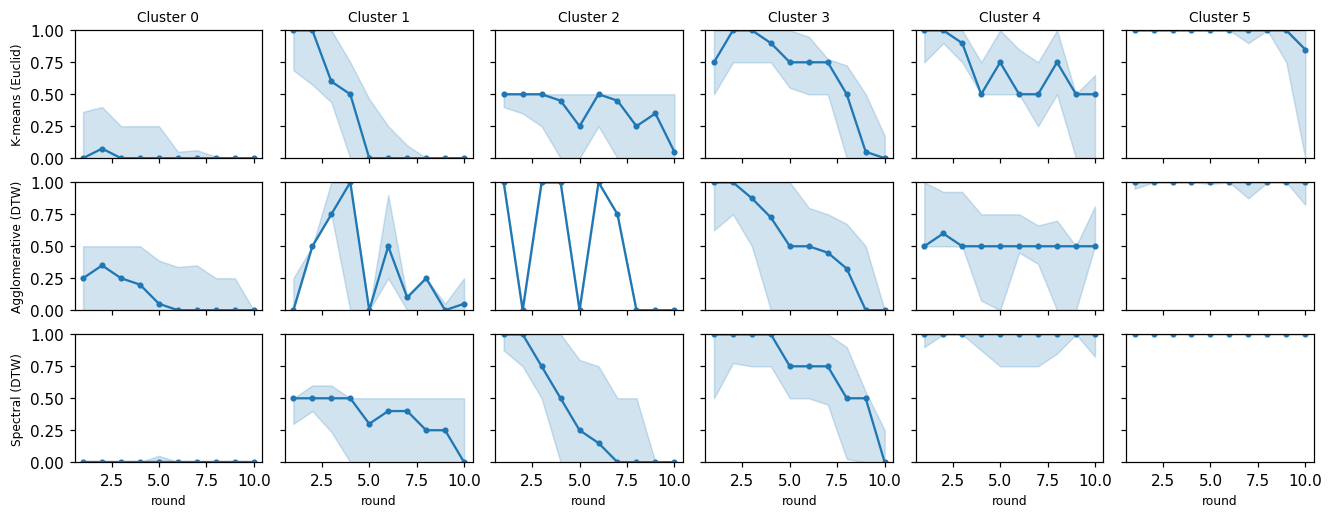

Pairwise Adjusted Rand Index (hard labels):
  K-means  vs Agglomer.: 0.28
  K-means  vs Spectral : 0.33
  Agglomer. vs Spectral: 0.27


In [11]:
k = 6
flat = tsd.reshape(tsd.shape[0], -1)  # 2-channel flattened for k-means
labels_km = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(flat)
labels_ag = AgglomerativeClustering(n_clusters=k, metric='precomputed',
                                     linkage='average').fit_predict(D)
labels_sp = SpectralClustering(n_clusters=k, affinity='precomputed',
                                random_state=42).fit_predict(S)

def relabel_by_mean(labels, series):
    """Renumber clusters so cluster 0 has the lowest mean, k-1 the highest."""
    means = {c: series[labels == c].mean() for c in np.unique(labels)}
    order = sorted(means, key=means.get)
    mapping = {old: new for new, old in enumerate(order)}
    return np.array([mapping[l] for l in labels])

labels_km = relabel_by_mean(labels_km, series_mean)
labels_ag = relabel_by_mean(labels_ag, series_mean)
labels_sp = relabel_by_mean(labels_sp, series_mean)

# Plot prototype trajectories (median + IQR) per cluster, one row per algorithm
algos = [('K-means (Euclid)',     labels_km),
         ('Agglomerative (DTW)',  labels_ag),
         ('Spectral (DTW)',       labels_sp)]

fig, axes = plt.subplots(len(algos), k, figsize=(2 * k, 1.2 * len(algos) + 1),
                         sharex=True, sharey=True, constrained_layout=True)
rounds = np.arange(1, 11)

for r, (name, labels) in enumerate(algos):
    for c in range(k):
        members = uids[labels == c]
        arr = np.stack([data[data['uid'] == u]['contr_nrmd'].values for u in members])
        p25, p50, p75 = np.percentile(arr, [25, 50, 75], axis=0)
        axes[r, c].fill_between(rounds, p25, p75, alpha=0.2, color='tab:blue')
        axes[r, c].plot(rounds, p50, color='tab:blue', marker='o', markersize=3)
        axes[r, c].set_ylim(0, 1)
        if r == 0:
            axes[r, c].set_title(f'Cluster {c}', fontsize=9)
        if c == 0:
            axes[r, c].set_ylabel(name, fontsize=8)
        if r == len(algos) - 1:
            axes[r, c].set_xlabel('round', fontsize=8)
plt.show()

# Quantify agreement: Adjusted Rand Index (1.0 = identical, 0 = random)
print('Pairwise Adjusted Rand Index (hard labels):')
print(f'  K-means  vs Agglomer.: {adjusted_rand_score(labels_km, labels_ag):.2f}')
print(f'  K-means  vs Spectral : {adjusted_rand_score(labels_km, labels_sp):.2f}')
print(f'  Agglomer. vs Spectral: {adjusted_rand_score(labels_ag, labels_sp):.2f}')

**Read across the rows.** Each row is a different algorithm. The six prototype shapes — roughly: stable free-rider, low decline, mid-level volatile, climbing, high conditional cooperator, full cooperator — appear in every row, in the same order. This is the paper's argument: step 3 is not where the action is.

The printed **Adjusted Rand Index** values look modest (~0.3). That is *not* a contradiction. ARI is computed on hard labels, so every participant who sits on a cluster boundary and flips between, say, cluster 2 and cluster 3 gets counted as a disagreement — even though both clusters describe recognisably the same type. The prototype plot above tells the substantive story; ARI tells you about boundary jitter.

**Takeaway.** Spend your methodological attention on **step 2** (what does "similar" mean?), because that's what actually shapes the result. Step 1 (`k`) is a judgement call, step 3 (algorithm) is almost free.

## 4. Put it all together: the 6 behavioural types

We keep the spectral + DTW result with `k = 6` and plot two views of each cluster:

- A **heatmap** of all participants in that cluster (rows = participants, columns = rounds). Shows within-cluster variation.
- A **median trajectory** with a 25–75th percentile band — the cluster's prototype story.

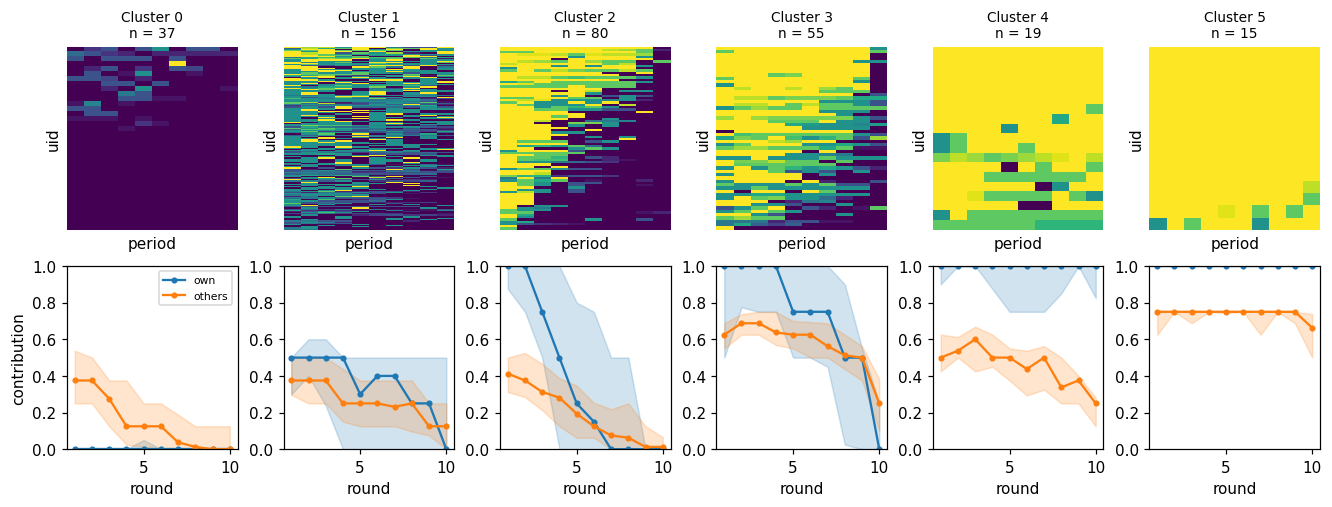

In [12]:
uid_to_cluster = dict(zip(uids, labels_sp))
data['cluster'] = data['uid'].map(uid_to_cluster)

fig, axes = plt.subplots(2, k, figsize=(2 * k, 4.5), constrained_layout=True)

for c in range(k):
    sub = data[data['cluster'] == c]
    cluster_uids = sub.groupby('uid')['contr_nrmd'].mean().sort_values(ascending=False).index

    # Top row: heatmap
    heat = sub.pivot(index='uid', columns='period', values='contr_nrmd').loc[cluster_uids]
    sns.heatmap(heat, ax=axes[0, c], cmap='viridis', vmin=0, vmax=1,
                cbar=False, xticklabels=False, yticklabels=False)
    axes[0, c].set_title(f'Cluster {c}\nn = {len(cluster_uids)}', fontsize=9)

    # Bottom row: median + IQR, for own and others'
    own_arr = np.stack([sub[sub['uid'] == u]['contr_nrmd'].values for u in cluster_uids])
    oth_arr = np.stack([sub[sub['uid'] == u]['contr_oth_nrmd'].values for u in cluster_uids])
    rounds_x = np.arange(1, own_arr.shape[1] + 1)
    for arr, color, lbl in [(own_arr, 'tab:blue', 'own'), (oth_arr, 'tab:orange', 'others')]:
        p25, p50, p75 = np.percentile(arr, [25, 50, 75], axis=0)
        axes[1, c].fill_between(rounds_x, p25, p75, alpha=0.2, color=color)
        axes[1, c].plot(rounds_x, p50, color=color, marker='o', markersize=3, label=lbl)
    axes[1, c].set_ylim(0, 1); axes[1, c].set_xlabel('round')
    if c == 0:
        axes[1, c].set_ylabel('contribution')
        axes[1, c].legend(fontsize=7, loc='upper right')
plt.show()

### A quick sanity check against the canonical typology

Twenty years of public-goods research have converged on a small menu of **behavioral types** (Houser 2004; Fallucci et al. 2019, 2021; Thöni & Volk 2018 for the meta-analysis):

- **Free riders** — contribute near zero throughout
- **Conditional cooperators** — match the group average
- **Unconditional cooperators** — contribute consistently high
- **"Others" / confused** — don't fit the above; typically 18–32% of participants across studies

Look at your clusters above. Can you label each one with one of these types? Which cluster doesn't fit? Hausladen, Engel & Schubert (2026) argue that a large fraction of the "confused/other" residual is actually a coherent type — **Switchers** — who cycle between cooperative and defective intentions and only show up once you combine DTW with a discrete-intention latent-variable model. That is the second half of the paper; this notebook is the first half.

## 5. What did we learn, and what are the open questions?

- Participants fall into a handful of **behavioural types** — not just cooperator vs free-rider, but also *patterns over time*: declining, climbing, oscillating.
- The **distance metric** does real work: DTW lets us group trajectories by *shape*, not by absolute timing. Feeding DTW *both* channels (own + others) is what turns behavioural *averages* into behavioural *strategies*.
- The **algorithm** is nearly a free parameter once the distance is right. Which is why the paper — and this notebook — spend most of the real estate on step 2.
- The **choice of `k`** is a judgement call. CVIs narrow the range, but the final call depends on whether the clusters tell a story an economist or political scientist would recognise. Here `k = 6` is both close to the CVI optimum and interpretable — hence the paper's choice.

### Transfer to the LLM literature (Week 3 prep)

The papers you are reading next week almost all report **aggregate** behavior — "GPT-4 cooperates X% of the time", "Claude defects after round Y". Re-read this notebook through that lens:

1. **Time alignment.** Akata et al. (2025) claim GPT-4 "never forgives" after a single defection. That is a *pointwise* claim. If GPT-4's unforgiving moment shifts position across runs (round 3 in one run, round 5 in another), Euclidean distance will call those runs dissimilar — but DTW might cluster them into a single "unforgiving" type. Which answer do we actually want?
2. **Heterogeneity across seeds/prompts.** Prompts are to LLMs what subjects are to experiments. Could you build a pairwise DTW matrix across prompt variants and cluster the model's *behavioral types* the way we clustered humans here?
3. **"Other/confused" as a real type.** Willis et al. (2025) and Fan et al. (2024) both find a residual fraction of LLM behavior that doesn't fit any clean strategic pattern. The PGG literature spent two decades calling this "trembles" before recognising it might be a type in its own right. What would convince *you* that an LLM's apparent inconsistency is a type, not noise?
4. **Intentions vs. actions.** Clustering gives you types defined by **actions**. Inverse RL — the next step in Hausladen et al. (2026) — gives you the underlying **reward function** / **intention**. Which one would you reach for if you wanted to answer: "is the LLM reasoning, or reproducing patterns?"

### Exercises

1. Swap DTW for plain Euclidean — compute `D_eu = squareform(pdist(flat))` and re-run spectral clustering. Do the 6 clusters survive?
2. Use only `contr_nrmd` (drop the others channel) when computing DTW. Does conditioning on others' behaviour matter? (Connects to the state-action schematic in §3.)
3. Re-run the CVI plot with random subsamples of 80% of participants. Is `k = 6` stable across subsamples?
4. Give each cluster a one-line *name* using the canonical typology above. Which cluster is hardest to name — and is that the "Switcher" type Hausladen et al. claim they can pick up with IRL?

### Suggested further reading

- **Hausladen, Engel & Schubert (2026)** — *Identifying Latent Intentions via IRL in Repeated Linear Public Good Games.* The full version of this pipeline (`papers/game theory/Hausladen_2026_PGGIntentions.pdf`).
- **Thöni & Volk (2018)** — *Conditional cooperation: Review and refinement.* The canonical behavioral-typology meta-analysis.
- **Fallucci, Renner & Sutter (2021)** — behavioral-type mixture models in PGGs.
- Aghabozorgi et al. (2015) — *Time-series clustering: A decade review.* Gentle survey.
- Berndt & Clifford (1994) — *Using DTW to find patterns in time series.* The original DTW paper.
- von Luxburg (2007) — *A tutorial on spectral clustering.* Why the Gaussian-kernel trick works.